# Cosmological Angular Power Spectra + MCMC
### With IPython Timing & Profiling (`%time`, `%timeit`, `%prun`, `%lprun`, `%memit`, `%mprun`)

## 0. Imports & Setup

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
import baccoemu
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator
from scipy.interpolate import interp1d, RectBivariateSpline
from scipy.integrate import simpson, cumulative_trapezoid
import os
from contextlib import redirect_stdout, redirect_stderr
import emcee
import corner
import h5py

warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)

## 1. Configuration

In [38]:
class Config:
    COSMO_PARAMS = {
        "Omega_m": 0.315,
        "Omega_b": 0.05,
        "h": 0.67,
        "n_s": 0.96,
        "sigma8": 0.83,
        "M_nu": 0.0,
        "w0": -1.0,
        "wa": 0.0,
        "aexp": 1.0,
    }
    c = 299792.458
    Z_MIN = 0.01
    Z_MAX = 1.5
    N_Z = 500
    N_Z_CHI = 2000
    Z0_GALAXY = 0.3
    ELL_MIN = 10
    ELL_MAX = 2000
    N_ELL = 50
    BIAS_B0 = 2.0
    alpha = 2.225
    FR_VALUES = [4, 5, 6]
    BACCO_K_MIN = -2
    BACCO_K_MAX = None
    BACCO_N_K = 200
    EMANTIS_VERBOSE = False
    FIGURE_SIZE = (14, 10)
    K_MIN_SAFETY = 1.1
    K_MAX_SAFETY = 0.9

## 2. Core Functions

In [39]:
def hubble_function(z, H0, Om_m, Om_lambda):
    z = np.asarray(z)
    return H0 * np.sqrt(
        Om_m * (1 + z) ** 3
        + (1 - Om_m - Om_lambda) * (1 + z) ** 2
        + Om_lambda
    )


def build_chi_interpolator(H0, Om_m, Om_lambda, n=None):
    n = n or Config.N_Z_CHI
    z_dense = np.linspace(0.0, Config.Z_MAX * 1.05, n)
    Hz = hubble_function(z_dense, H0, Om_m, Om_lambda)
    chi_dense = np.concatenate(
        [[0.0], cumulative_trapezoid(Config.c / Hz, z_dense)]
    )
    return interp1d(z_dense, chi_dense, kind="cubic",
                    bounds_error=False, fill_value="extrapolate")


def compute_Omega_z(z, H0, Om_m, Om_lambda):
    num = Om_m * (1 + z) ** 3
    den = Om_m * (1 + z) ** 3 + (1 - Om_m - Om_lambda) * (1 + z) ** 2 + Om_lambda
    return num / den


def compute_lambda_z(z, H0, Om_m, Om_lambda):
    num = Om_lambda
    den = Om_m * (1 + z) ** 3 + (1 - Om_m - Om_lambda) * (1 + z) ** 2 + Om_lambda
    return num / den


def growth_function_g(z, H0, Om_m, Om_lambda):
    Omega_z = compute_Omega_z(z, H0, Om_m, Om_lambda)
    lambda_z = compute_lambda_z(z, H0, Om_m, Om_lambda)
    den = Omega_z ** (4 / 7) - lambda_z + (1 + Omega_z / 2) * (1 + lambda_z / 70)
    return (5 * Omega_z / 2) * (1 / den)


def growth_factor_D(z, H0, Om_m, Om_lambda):
    z = np.asarray(z)
    g_z = growth_function_g(z, H0, Om_m, Om_lambda)
    g_0 = growth_function_g(0.0, H0, Om_m, Om_lambda)
    return (g_z / (1.0 + z)) / g_0


def bias_function(z, H0, Omega_m, Omega_lambda, b0=1.0):
    D_z = growth_factor_D(z, H0, Omega_m, Omega_lambda)
    D_0 = growth_factor_D(0.0, H0, Omega_m, Omega_lambda)
    return b0 / (D_z / D_0 + 1e-30)


def cmb_lensing_kernel_vec(z_grid, z_star, H0, Om_m, Om_lambda, chi_of_z):
    Hz = hubble_function(z_grid, H0, Om_m, Om_lambda)
    prefactor = (3 * Om_m * H0 ** 2) / (2 * Config.c * Hz)
    chi_z = chi_of_z(z_grid)
    chi_star = float(chi_of_z(z_star))
    return prefactor * (1 + z_grid) * chi_z * (chi_star - chi_z) / chi_star


def galaxy_lensing_kernel_vec(z_grid, dNdz_arr, bias_arr, H0, Om_m, Om_lambda, chi_of_z):
    chi_z = chi_of_z(z_grid)
    Hz = hubble_function(z_grid, H0, Om_m, Om_lambda)
    alpha_minus1 = Config.alpha - 1.0
    f_A = alpha_minus1 * dNdz_arr
    f_B = alpha_minus1 * dNdz_arr / (chi_z + 1e-30)

    def suffix_trapz(f, z):
        ct = cumulative_trapezoid(f[::-1], z[::-1], initial=0.0)
        return ct[::-1]

    A_suffix = suffix_trapz(f_A, z_grid)
    B_suffix = suffix_trapz(f_B, z_grid)
    mag_integral = A_suffix - chi_z * B_suffix
    mu_prefactor = (3 * Om_m * H0 ** 2) / (2 * Config.c * Hz) * (1 + z_grid) * chi_z
    return bias_arr * dNdz_arr + mu_prefactor * mag_integral

In [40]:
def initialize_bacco_emulator(params, k_min=-2, k_max=None, n_k=200, verbose=False):
    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            emulator = baccoemu.Matter_powerspectrum(verbose=verbose)
            if k_max is None:
                k_max = np.log10(emulator.emulator["nonlinear"]["k"].max())
            k = np.logspace(k_min, k_max, num=n_k)
    return emulator, k


def initialize_emantis_emulator(verbose=False):
    return NonLinearMGBoostEmulator(verbose=verbose)


def _bacco_params(params):
    return {
        "omega_cold": params["Omega_m"] - params["Omega_b"],
        "sigma8_cold": params["sigma8"],
        "omega_baryon": params["Omega_b"],
        "ns": params["n_s"],
        "hubble": params["h"],
        "neutrino_mass": params.get("M_nu", 0.0),
        "w0": params.get("w0", -1.0),
        "wa": params.get("wa", 0.0),
    }


def build_pk_spline_gr(emulator, params, k, z_grid):
    bp = _bacco_params(params)
    log_k = np.log(k)
    pk_2d = np.empty((len(k), len(z_grid)))
    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            for j, z in enumerate(z_grid):
                _, pk_nl = emulator.get_nonlinear_pk(
                    k=k, cold=False, expfactor=1.0 / (1.0 + z), **bp
                )
                pk_2d[:, j] = pk_nl
    return RectBivariateSpline(log_k, z_grid, np.log(pk_2d + 1e-50), kx=3, ky=3)


def build_pk_spline_fr(emulator, emantis_emu, params, logfR0, k, z_grid):
    bp = _bacco_params(params)
    ep = {
        "Omega_m": params["Omega_m"],
        "Omega_b": params["Omega_b"],
        "h": params["h"],
        "n_s": params["n_s"],
        "sigma8_lcdm": params["sigma8"],
        "logfR0": logfR0,
    }
    log_k = np.log(k)
    pk_2d = np.empty((len(k), len(z_grid)))
    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            for j, z in enumerate(z_grid):
                aexp = 1.0 / (1.0 + z)
                _, pk_gr = emulator.get_nonlinear_pk(
                    k=k, cold=False, expfactor=aexp, **bp
                )
                boost = emantis_emu.predict_boost(ep, aexp=aexp, k=k)
                pk_2d[:, j] = pk_gr * boost
    return RectBivariateSpline(log_k, z_grid, np.log(pk_2d + 1e-50), kx=3, ky=3)


def compute_Cl_vec(ell_array, pk_spline, z_grid, Wg_vals, Wkappa_vals,
                   chi_vals, H_vals, h, c_light, k_min=None, k_max=None, cross=False):
    chi_h = chi_vals * h
    k_vals = (ell_array[:, None] + 0.5) / chi_h[None, :]
    if k_min is not None:
        k_vals = np.clip(k_vals, k_min, k_max)
    log_P_flat = pk_spline(
        np.log(k_vals).ravel(), np.tile(z_grid, len(ell_array)), grid=False
    )
    P_kz = np.exp(log_P_flat).reshape(len(ell_array), len(z_grid)) / h ** 3
    W_product = (Wkappa_vals * Wg_vals)[None, :] if cross else Wg_vals[None, :] ** 2
    integrand = (H_vals[None, :] / c_light) * W_product * P_kz / chi_vals[None, :] ** 2
    return simpson(integrand, z_grid, axis=1)

## 3. Caching Helpers & MCMC Model

In [41]:
_ROUND = 5
_geo_cache = {}
_pk_cache = {}
_GEO_MAXSIZE = 128
_PK_MAXSIZE = 128


def _evict(cache, maxsize):
    if len(cache) >= maxsize:
        del cache[next(iter(cache))]


def get_geometry(Omega_m, b0, z_grid_local, z_star):
    key = (round(float(Omega_m), _ROUND), round(float(b0), _ROUND))
    if key in _geo_cache:
        return _geo_cache[key]
    H0_loc = Config.COSMO_PARAMS["h"] * 100.0
    Om_m_loc = float(Omega_m)
    Om_lam_loc = 1.0 - Om_m_loc
    chi_of_z_loc = build_chi_interpolator(H0_loc, Om_m_loc, Om_lam_loc)
    chi_loc = chi_of_z_loc(z_grid_local)
    H_loc = hubble_function(z_grid_local, H0_loc, Om_m_loc, Om_lam_loc)
    raw_nz = (2.0 * Config.Z0_GALAXY) * (z_grid_local / Config.Z0_GALAXY) ** 2 \
             * np.exp(-z_grid_local / Config.Z0_GALAXY)
    dNdz_loc = raw_nz / simpson(raw_nz, z_grid_local)
    Wkap_loc = cmb_lensing_kernel_vec(z_grid_local, z_star, H0_loc, Om_m_loc, Om_lam_loc, chi_of_z_loc)
    bias_loc = bias_function(z_grid_local, H0_loc, Om_m_loc, Om_lam_loc, b0=float(b0))
    Wg_loc = galaxy_lensing_kernel_vec(z_grid_local, dNdz_loc, bias_loc, H0_loc, Om_m_loc, Om_lam_loc, chi_of_z_loc)
    result = dict(H0=H0_loc, Om_m=Om_m_loc, Om_lam=Om_lam_loc,
                  chi=chi_loc, H=H_loc, Wkappa=Wkap_loc, Wg=Wg_loc)
    _evict(_geo_cache, _GEO_MAXSIZE)
    _geo_cache[key] = result
    return result


def get_pk_spline(Omega_m, sigma8, logfR0, z_grid_local, bacco_emu, emantis_emu, k):
    key = (round(float(Omega_m), _ROUND), round(float(sigma8), _ROUND), round(float(logfR0), _ROUND))
    if key in _pk_cache:
        return _pk_cache[key]
    params = Config.COSMO_PARAMS.copy()
    params["Omega_m"] = float(Omega_m)
    params["sigma8"] = float(sigma8)
    spline = build_pk_spline_fr(bacco_emu, emantis_emu, params, abs(float(logfR0)), k, z_grid_local)
    _evict(_pk_cache, _PK_MAXSIZE)
    _pk_cache[key] = spline
    return spline


def model_cls_fast(theta, ell_local, z_grid_local, z_star, bacco_emu, emantis_emu, k, k_min_safe, k_max_safe):
    Omega_m, sigma8, b0, logfR0 = theta
    geo = get_geometry(Omega_m, b0, z_grid_local, z_star)
    spline = get_pk_spline(Omega_m, sigma8, logfR0, z_grid_local, bacco_emu, emantis_emu, k)
    shared_kw = dict(
        z_grid=z_grid_local,
        Wg_vals=geo["Wg"], Wkappa_vals=geo["Wkappa"],
        chi_vals=geo["chi"], H_vals=geo["H"],
        h=Config.COSMO_PARAMS["h"], c_light=Config.c,
        k_min=k_min_safe, k_max=k_max_safe,
    )
    Cl_gg = compute_Cl_vec(ell_local, spline, cross=False, **shared_kw)
    Cl_kg = compute_Cl_vec(ell_local, spline, cross=True, **shared_kw)
    return Cl_gg, Cl_kg


def flatten_cls(Cl_gg, Cl_kg):
    return np.concatenate([Cl_gg, Cl_kg])

## 4. Initialize Emulators

We time the initialization of both emulators using `%time` (single execution, no repeat).

In [42]:
PLOT_OUTPUT_DIR = "mcmc_plots"
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

H0 = Config.COSMO_PARAMS["h"] * 100.0
Om_m = Config.COSMO_PARAMS["Omega_m"]
Om_lambda = 1.0 - Om_m
z_star = 1100.0

In [43]:
%time bacco_emu, k = initialize_bacco_emulator(Config.COSMO_PARAMS, k_min=Config.BACCO_K_MIN, k_max=Config.BACCO_K_MAX, n_k=Config.BACCO_N_K, verbose=Config.EMANTIS_VERBOSE)

CPU times: user 20.7 ms, sys: 2.04 ms, total: 22.7 ms
Wall time: 21.7 ms


In [44]:
%time emantis_emu = initialize_emantis_emulator(verbose=Config.EMANTIS_VERBOSE)

k_min_safe = k.min() * Config.K_MIN_SAFETY
k_max_safe = k.max() * Config.K_MAX_SAFETY

CPU times: user 18.2 ms, sys: 5.97 ms, total: 24.1 ms
Wall time: 23.1 ms


## 5. Build Geometry & Kernels

`%timeit` is used for the comoving distance interpolator — a fast, repeatable operation where we want a stable average.

In [45]:
z_grid = np.linspace(Config.Z_MIN, Config.Z_MAX, Config.N_Z)

# %timeit — repeated timing for fast operations
%timeit build_chi_interpolator(H0, Om_m, Om_lambda)

711 μs ± 59.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [46]:
chi_of_z = build_chi_interpolator(H0, Om_m, Om_lambda)
chi_vals = chi_of_z(z_grid)
H_vals = hubble_function(z_grid, H0, Om_m, Om_lambda)

_raw_nz = (2.0 * Config.Z0_GALAXY) * (z_grid / Config.Z0_GALAXY) ** 2 \
          * np.exp(-z_grid / Config.Z0_GALAXY)
dNdz = _raw_nz / simpson(_raw_nz, z_grid)

Wkappa_vals = cmb_lensing_kernel_vec(z_grid, z_star, H0, Om_m, Om_lambda, chi_of_z)
bias_arr = bias_function(z_grid, H0, Om_m, Om_lambda, b0=Config.BIAS_B0)
Wg_vals = galaxy_lensing_kernel_vec(z_grid, dNdz, bias_arr, H0, Om_m, Om_lambda, chi_of_z)

# %timeit on the lensing kernel (vectorised — good candidate for repeated timing)
%timeit cmb_lensing_kernel_vec(z_grid, z_star, H0, Om_m, Om_lambda, chi_of_z)

86 μs ± 3.21 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## 6. Build GR Power Spectrum Spline

`%time` is appropriate here — the loop over redshift bins is expensive and we only want one run.

In [47]:
%time pk_spline_gr = build_pk_spline_gr(bacco_emu, Config.COSMO_PARAMS, k, z_grid)

CPU times: user 4.94 s, sys: 221 ms, total: 5.16 s
Wall time: 3.72 s


## 7. Compute Angular Power Spectra (GR + f(R))

`%timeit` on `compute_Cl_vec` — fully vectorised, fast, benefits from repeated measurement.

In [48]:
ell = np.logspace(np.log10(Config.ELL_MIN), np.log10(Config.ELL_MAX), Config.N_ELL)
shared = dict(
    z_grid=z_grid, Wg_vals=Wg_vals, Wkappa_vals=Wkappa_vals,
    chi_vals=chi_vals, H_vals=H_vals, h=Config.COSMO_PARAMS["h"],
    c_light=Config.c, k_min=k_min_safe, k_max=k_max_safe,
)

%timeit compute_Cl_vec(ell, pk_spline_gr, cross=False, **shared)

10.8 ms ± 507 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [49]:
Cl_gg_gr = compute_Cl_vec(ell, pk_spline_gr, cross=False, **shared)
Cl_kg_gr = compute_Cl_vec(ell, pk_spline_gr, cross=True, **shared)

### 7a. f(R) spectra — time with `%%time` (multi-line cell)

In [50]:
%%time
fr_results = {"gg": {}, "kg": {}}
for logfR0_val in Config.FR_VALUES:
    pk_spline_fr = build_pk_spline_fr(bacco_emu, emantis_emu, Config.COSMO_PARAMS, logfR0_val, k, z_grid)
    fr_results["gg"][logfR0_val] = compute_Cl_vec(ell, pk_spline_fr, cross=False, **shared)
    fr_results["kg"][logfR0_val] = compute_Cl_vec(ell, pk_spline_fr, cross=True, **shared)

CPU times: user 19 s, sys: 719 ms, total: 19.7 s
Wall time: 14.8 s


## 8. Function-Level Profiling with `%prun`

`%prun` profiles every function call inside `build_pk_spline_fr`, showing where execution time is actually spent.

In [51]:
%prun build_pk_spline_fr(bacco_emu, emantis_emu, Config.COSMO_PARAMS, 5, k, z_grid)

         5707026 function calls (5418513 primitive calls) in 7.567 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    24000    0.686    0.000    0.852    0.000 ufunc_api.py:175(__call__)
     3000    0.522    0.000    1.282    0.000 utils.py:24(predict)
284000/7500    0.437    0.000    1.327    0.000 copy.py:118(deepcopy)
3000/2000    0.324    0.000    2.669    0.001 matter_powerspectrum.py:121(_get_parameters)
    80975    0.246    0.000    0.246    0.000 {method 'reduce' of 'numpy.ufunc' objects}
356986/356982    0.142    0.000    0.203    0.000 {built-in method builtins.isinstance}
   611971    0.141    0.000    0.141    0.000 {method 'get' of 'dict' objects}
     4000    0.140    0.000    0.156    0.000 dispatch.py:83(apply_primitive)
     4995    0.134    0.000    0.257    0.000 kernels.py:1680(__call__)
     1000    0.131    0.000    3.105    0.003 matter_powerspectrum.py:810(get_linear_pk)
     7992    0.126    0.00

In [52]:
# Also profile compute_Cl_vec — this is the inner loop in MCMC
%prun -s cumulative compute_Cl_vec(ell, pk_spline_gr, cross=False, **shared)

         665 function calls (660 primitive calls) in 0.013 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000    0.012    0.012 {built-in method builtins.exec}
        1    0.000    0.000    0.008    0.008 decorator.py:232(fun)
        1    0.000    0.000    0.008    0.008 history.py:100(only_when_enabled)
        1    0.000    0.000    0.008    0.008 history.py:1055(writeout_cache)
        1    0.000    0.000    0.007    0.007 history.py:1039(_writeout_input_cache)
        2    0.007    0.003    0.007    0.003 {method '__exit__' of 'sqlite3.Connection' objects}
        1    0.000    0.000    0.004    0.004 <string>:1(<module>)
        1    0.000    0.000    0.004    0.004 2975391734.py:66(compute_Cl_vec)
        1    0.003    0.003    0.003    0.003 _fitpack2.py:978(__call__)
        1    0.000    0.000    0.001    0.001 {method 'execute' of 'sqlite3.Connection' objects}
        1    0.001    0.0

## 9. Line-by-Line Profiling with `%lprun`

`%lprun` pinpoints which *lines* inside a function dominate execution time.

In [53]:
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [54]:
# Profile compute_Cl_vec line-by-line
%lprun -f compute_Cl_vec compute_Cl_vec(ell, pk_spline_gr, cross=False, **shared)

Timer unit: 1e-09 s

Total time: 0.0121967 s
File: /tmp/ipykernel_353673/2975391734.py
Function: compute_Cl_vec at line 66

Line #      Hits         Time  Per Hit   % Time  Line Contents
    66                                           def compute_Cl_vec(ell_array, pk_spline, z_grid, Wg_vals, Wkappa_vals,
    67                                                              chi_vals, H_vals, h, c_light, k_min=None, k_max=None, cross=False):
    68         1      23620.0  23620.0      0.2      chi_h = chi_vals * h
    69         1     532002.0 532002.0      4.4      k_vals = (ell_array[:, None] + 0.5) / chi_h[None, :]
    70         1        580.0    580.0      0.0      if k_min is not None:
    71         1    1065974.0 1.07e+06      8.7          k_vals = np.clip(k_vals, k_min, k_max)
    72         2    9580570.0 4.79e+06     78.6      log_P_flat = pk_spline(
    73         1     285221.0 285221.0      2.3          np.log(k_vals).ravel(), np.tile(z_grid, len(ell_array)), grid=False
    

In [55]:
# Profile galaxy_lensing_kernel_vec line-by-line
%lprun -f galaxy_lensing_kernel_vec galaxy_lensing_kernel_vec(z_grid, dNdz, bias_arr, H0, Om_m, Om_lambda, chi_of_z)

Timer unit: 1e-09 s

Total time: 0.000623732 s
File: /tmp/ipykernel_353673/2123920325.py
Function: galaxy_lensing_kernel_vec at line 61

Line #      Hits         Time  Per Hit   % Time  Line Contents
    61                                           def galaxy_lensing_kernel_vec(z_grid, dNdz_arr, bias_arr, H0, Om_m, Om_lambda, chi_of_z):
    62         1     176260.0 176260.0     28.3      chi_z = chi_of_z(z_grid)
    63         1      43651.0  43651.0      7.0      Hz = hubble_function(z_grid, H0, Om_m, Om_lambda)
    64         1        920.0    920.0      0.1      alpha_minus1 = Config.alpha - 1.0
    65         1       2540.0   2540.0      0.4      f_A = alpha_minus1 * dNdz_arr
    66         1       5910.0   5910.0      0.9      f_B = alpha_minus1 * dNdz_arr / (chi_z + 1e-30)
    67                                           
    68         1        780.0    780.0      0.1      def suffix_trapz(f, z):
    69                                                   ct = cumulative_trapezoid

## 10. Memory Profiling with `%memit`

`%memit` reports peak memory usage — useful for large P(k) arrays and spline objects.

In [56]:
%load_ext memory_profiler

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


In [57]:
# Memory cost of building the GR P(k) spline
%memit build_pk_spline_gr(bacco_emu, Config.COSMO_PARAMS, k, z_grid)

peak memory: 496.31 MiB, increment: 0.01 MiB


In [58]:
# Memory cost of a single Cl computation
%memit compute_Cl_vec(ell, pk_spline_gr, cross=False, **shared)

peak memory: 496.59 MiB, increment: 0.27 MiB


## 11. Line-by-Line Memory Profiling with `%mprun`

`%mprun` requires functions defined in a **separate module file** (not in the notebook itself).

In [59]:
%%file mprun_cosmo_demo.py
import numpy as np
from scipy.integrate import simpson, cumulative_trapezoid
from scipy.interpolate import RectBivariateSpline
import os
from contextlib import redirect_stdout, redirect_stderr

def compute_Cl_vec_mprun(ell_array, pk_spline, z_grid, Wg_vals, Wkappa_vals,
                          chi_vals, H_vals, h, c_light, k_min=None, k_max=None, cross=False):
    chi_h = chi_vals * h
    k_vals = (ell_array[:, None] + 0.5) / chi_h[None, :]
    if k_min is not None:
        k_vals = np.clip(k_vals, k_min, k_max)
    log_P_flat = pk_spline(
        np.log(k_vals).ravel(), np.tile(z_grid, len(ell_array)), grid=False
    )
    P_kz = np.exp(log_P_flat).reshape(len(ell_array), len(z_grid)) / h ** 3
    W_product = (Wkappa_vals * Wg_vals)[None, :] if cross else Wg_vals[None, :] ** 2
    integrand = (H_vals[None, :] / c_light) * W_product * P_kz / chi_vals[None, :] ** 2
    return simpson(integrand, z_grid, axis=1)


def build_pk_spline_gr_mprun(emulator, params, k, z_grid):
    omega_cold = params["Omega_m"] - params["Omega_b"]
    bp = {
        "omega_cold": omega_cold,
        "sigma8_cold": params["sigma8"],
        "omega_baryon": params["Omega_b"],
        "ns": params["n_s"],
        "hubble": params["h"],
        "neutrino_mass": params.get("M_nu", 0.0),
        "w0": params.get("w0", -1.0),
        "wa": params.get("wa", 0.0),
    }
    log_k = np.log(k)
    pk_2d = np.empty((len(k), len(z_grid)))
    with open(os.devnull, "w") as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            for j, z in enumerate(z_grid):
                _, pk_nl = emulator.get_nonlinear_pk(
                    k=k, cold=False, expfactor=1.0 / (1.0 + z), **bp
                )
                pk_2d[:, j] = pk_nl
    return RectBivariateSpline(log_k, z_grid, np.log(pk_2d + 1e-50), kx=3, ky=3)

Overwriting mprun_cosmo_demo.py


In [60]:
from mprun_cosmo_demo import compute_Cl_vec_mprun, build_pk_spline_gr_mprun

# Line-by-line memory profile of compute_Cl_vec
%mprun -f compute_Cl_vec_mprun compute_Cl_vec_mprun(ell, pk_spline_gr, z_grid, Wg_vals, Wkappa_vals, chi_vals, H_vals, Config.COSMO_PARAMS["h"], Config.c, k_min_safe, k_max_safe)

Filename: /home/adrita_khan/practice/mprun_cosmo_demo.py

Line #    Mem usage    Increment  Occurrences   Line Contents
     7    496.6 MiB    496.6 MiB           1   def compute_Cl_vec_mprun(ell_array, pk_spline, z_grid, Wg_vals, Wkappa_vals,
     8                                                                   chi_vals, H_vals, h, c_light, k_min=None, k_max=None, cross=False):
     9    496.6 MiB      0.0 MiB           1       chi_h = chi_vals * h
    10    496.6 MiB      0.0 MiB           1       k_vals = (ell_array[:, None] + 0.5) / chi_h[None, :]
    11    496.6 MiB      0.0 MiB           1       if k_min is not None:
    12    496.6 MiB      0.0 MiB           1           k_vals = np.clip(k_vals, k_min, k_max)
    13    496.6 MiB      0.0 MiB           2       log_P_flat = pk_spline(
    14    496.6 MiB      0.0 MiB           1           np.log(k_vals).ravel(), np.tile(z_grid, len(ell_array)), grid=False
    15                                             )
    16    496.6 MiB  

In [61]:
# Use a coarser z_grid to keep mprun fast
z_grid_coarse = np.linspace(Config.Z_MIN, Config.Z_MAX, 30)

%mprun -f build_pk_spline_gr_mprun build_pk_spline_gr_mprun(bacco_emu, Config.COSMO_PARAMS, k, z_grid_coarse)

Filename: /home/adrita_khan/practice/mprun_cosmo_demo.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    22    496.6 MiB    496.6 MiB           1   def build_pk_spline_gr_mprun(emulator, params, k, z_grid):
    23    496.6 MiB      0.0 MiB           1       omega_cold = params["Omega_m"] - params["Omega_b"]
    24    496.6 MiB      0.0 MiB           1       bp = {
    25    496.6 MiB      0.0 MiB           1           "omega_cold": omega_cold,
    26    496.6 MiB      0.0 MiB           1           "sigma8_cold": params["sigma8"],
    27    496.6 MiB      0.0 MiB           1           "omega_baryon": params["Omega_b"],
    28    496.6 MiB      0.0 MiB           1           "ns": params["n_s"],
    29    496.6 MiB      0.0 MiB           1           "hubble": params["h"],
    30    496.6 MiB      0.0 MiB           1           "neutrino_mass": params.get("M_nu", 0.0),
    31    496.6 MiB      0.0 MiB           1           "w0": params.get("w0", -1.0),
    32    496.6 MiB

## 12. Plot Power Spectra

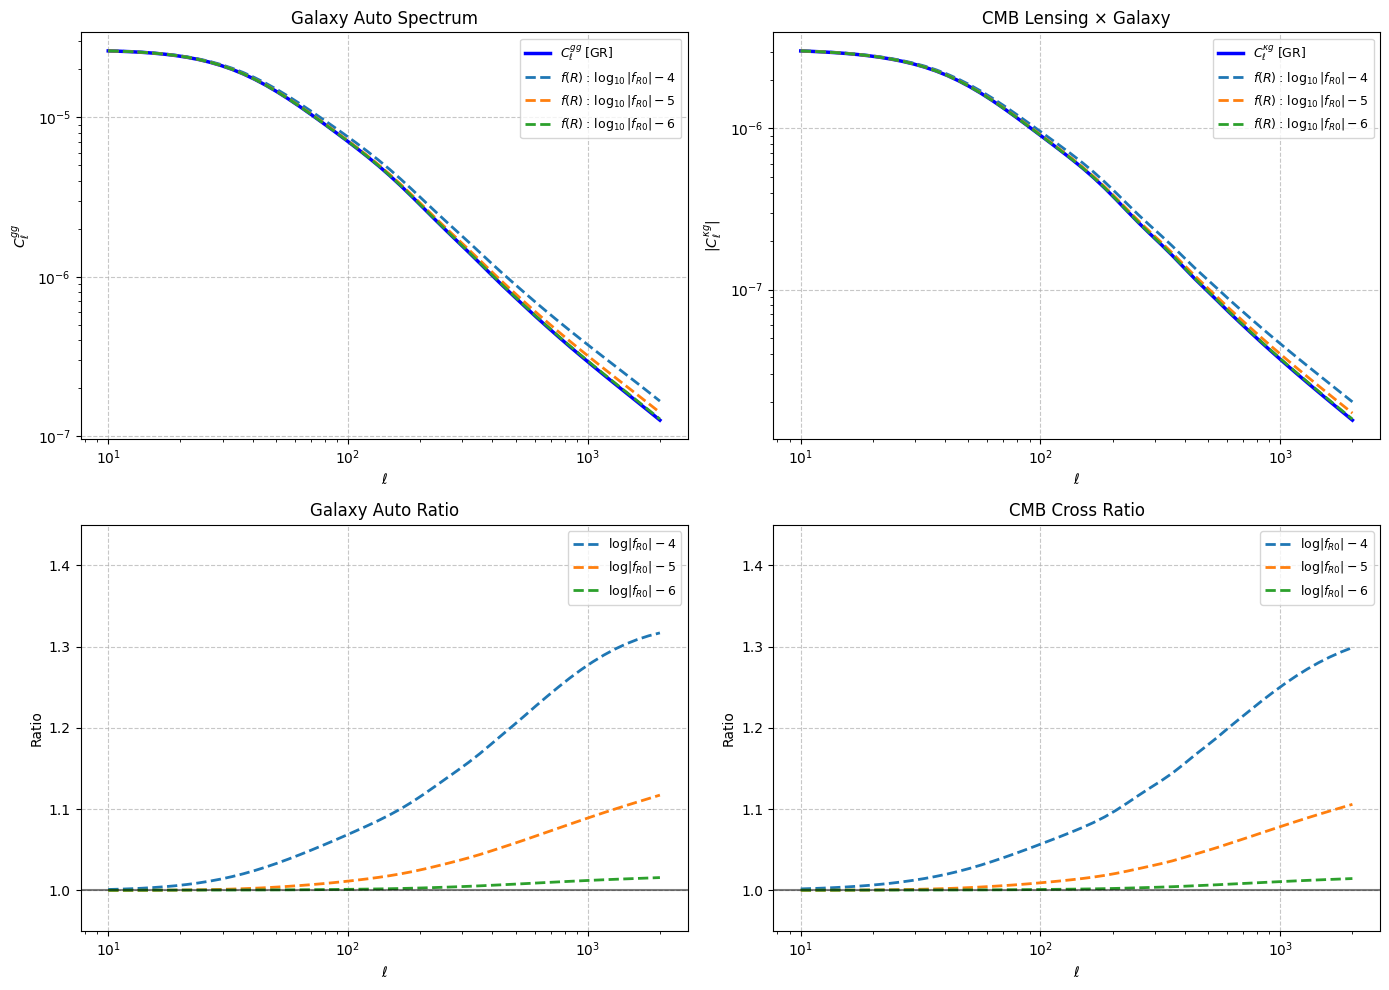

In [62]:
def plot_power_spectra(ell, Cl_gg_gr, Cl_kg_gr, fr_results=None,
                       fR_values=None, figsize=(14, 10)):
    fig = plt.figure(figsize=figsize)

    plt.subplot(2, 2, 1)
    plt.loglog(ell, Cl_gg_gr, "b-", linewidth=2.5, label=r"$C_\ell^{gg}\;[\mathrm{GR}]$")
    if fr_results and fR_values:
        for v in fR_values:
            if v in fr_results["gg"]:
                plt.loglog(ell, fr_results["gg"][v], "--", linewidth=2,
                           label=rf"$f(R):\,\log_{{10}}|f_{{R0}}|-{v}$")
    plt.xlabel(r"$\ell$"); plt.ylabel(r"$C_\ell^{gg}$")
    plt.title(r"Galaxy Auto Spectrum"); plt.legend(fontsize=9); plt.grid(ls="--", alpha=0.7)

    plt.subplot(2, 2, 2)
    plt.loglog(ell, np.abs(Cl_kg_gr), "b-", linewidth=2.5, label=r"$C_\ell^{\kappa g}\;[\mathrm{GR}]$")
    if fr_results and fR_values:
        for v in fR_values:
            if v in fr_results["kg"]:
                plt.loglog(ell, np.abs(fr_results["kg"][v]), "--", linewidth=2,
                           label=rf"$f(R):\,\log_{{10}}|f_{{R0}}|-{v}$")
    plt.xlabel(r"$\ell$"); plt.ylabel(r"$|C_\ell^{\kappa g}|$")
    plt.title(r"CMB Lensing × Galaxy"); plt.legend(fontsize=9); plt.grid(ls="--", alpha=0.7)

    plt.subplot(2, 2, 3)
    if fr_results and fR_values:
        for v in fR_values:
            if v in fr_results["gg"]:
                plt.semilogx(ell, fr_results["gg"][v] / Cl_gg_gr, "--", linewidth=2,
                             label=rf"$\log|f_{{R0}}|-{v}$")
        plt.axhline(1.0, color="k", lw=1.5, alpha=0.5)
    plt.xlabel(r"$\ell$"); plt.ylabel(r"Ratio"); plt.title(r"Galaxy Auto Ratio")
    plt.legend(fontsize=9); plt.grid(ls="--", alpha=0.7); plt.ylim([0.95, 1.45])

    plt.subplot(2, 2, 4)
    if fr_results and fR_values:
        for v in fR_values:
            if v in fr_results["kg"]:
                plt.semilogx(ell, fr_results["kg"][v] / Cl_kg_gr, "--", linewidth=2,
                             label=rf"$\log|f_{{R0}}|-{v}$")
        plt.axhline(1.0, color="k", lw=1.5, alpha=0.5)
    plt.xlabel(r"$\ell$"); plt.ylabel(r"Ratio"); plt.title(r"CMB Cross Ratio")
    plt.legend(fontsize=9); plt.grid(ls="--", alpha=0.7); plt.ylim([0.95, 1.45])

    plt.tight_layout()
    return fig


fig = plot_power_spectra(ell, Cl_gg_gr, Cl_kg_gr,
                         fr_results=fr_results, fR_values=Config.FR_VALUES,
                         figsize=Config.FIGURE_SIZE)
fig.savefig(os.path.join(PLOT_OUTPUT_DIR, "power_spectra_gr_vs_fr.png"), dpi=300, bbox_inches="tight")
plt.show()

## 13. MCMC Setup

In [63]:
PARAM_NAMES = [r"$\Omega_m$", r"$\sigma_8$", r"$b_0$", r"$\log_{10}|f_{R0}|$"]
FIDUCIAL_THETA = np.array([Config.COSMO_PARAMS["Omega_m"], Config.COSMO_PARAMS["sigma8"], Config.BIAS_B0, -5.0])
PRIORS = {"Omega_m": (0.20, 0.45), "sigma8": (0.60, 1.00), "b0": (0.50, 4.00), "logfR0": (-6.00, -4.00)}

N_Z_MCMC = 80
N_ELL_MCMC = 20
ELL_MIN_MCMC = Config.ELL_MIN
ELL_MAX_MCMC = 1200
STAT_FRAC_ERR_GG = 0.05
STAT_FRAC_ERR_KG = 0.08
N_WALKERS = 32
N_STEPS = 800
BURN_IN = 200
THIN = 5
HDF5_CHAIN_FILE = "emcee_clgg_clkg_chain.h5"
HDF5_BACKEND_NAME = "mcmc"
RESET_HDF5_BACKEND = True
CHECK_AUTOCORR_EVERY = 100

np.random.seed(42)

ell_mcmc = np.logspace(np.log10(ELL_MIN_MCMC), np.log10(ELL_MAX_MCMC), N_ELL_MCMC)
z_grid_mcmc = np.linspace(Config.Z_MIN, Config.Z_MAX, N_Z_MCMC)

### 13a. Time a single fiducial model evaluation

This is the inner loop of MCMC — knowing its cost is critical.

In [64]:
%%time
# First call builds caches — time it separately

Cl_gg_fid, Cl_kg_fid = model_cls_fast(
    FIDUCIAL_THETA,
    ell_mcmc,
    z_grid_mcmc,
    z_star,
    bacco_emu,
    emantis_emu,
    k,
    k_min_safe,
    k_max_safe,
)

CPU times: user 1.03 s, sys: 31.1 ms, total: 1.06 s
Wall time: 809 ms


In [65]:
%%timeit
# Subsequent calls hit the cache — timeit gives the cached cost

model_cls_fast(
    FIDUCIAL_THETA,
    ell_mcmc,
    z_grid_mcmc,
    z_star,
    bacco_emu,
    emantis_emu,
    k,
    k_min_safe,
    k_max_safe,
)

1.56 ms ± 199 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


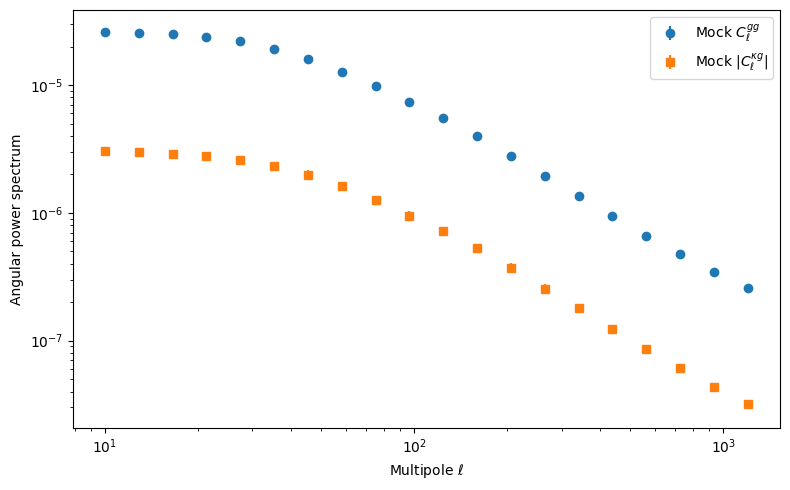

In [66]:
data_vector = flatten_cls(Cl_gg_fid, Cl_kg_fid)
sigma_gg = STAT_FRAC_ERR_GG * np.abs(Cl_gg_fid)
sigma_kg = STAT_FRAC_ERR_KG * np.maximum(np.abs(Cl_kg_fid), 1e-30)
sigma_vector = flatten_cls(sigma_gg, sigma_kg)

fig = plt.figure(figsize=(8, 5))
plt.errorbar(ell_mcmc, Cl_gg_fid, yerr=sigma_gg, fmt="o", label=r"Mock $C_\ell^{gg}$")
plt.errorbar(ell_mcmc, np.abs(Cl_kg_fid), yerr=sigma_kg, fmt="s", label=r"Mock $|C_\ell^{\kappa g}|$")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"Multipole $\ell$"); plt.ylabel(r"Angular power spectrum")
plt.legend(); plt.tight_layout()
fig.savefig(os.path.join(PLOT_OUTPUT_DIR, "mock_data_vector.png"), dpi=300, bbox_inches="tight")
plt.show()

## 14. MCMC Log-Probability Functions

In [67]:
def log_prior(theta):
    Omega_m, sigma8, b0, logfR0 = theta
    if not (PRIORS["Omega_m"][0] < Omega_m < PRIORS["Omega_m"][1]): return -np.inf
    if not (PRIORS["sigma8"][0] < sigma8 < PRIORS["sigma8"][1]): return -np.inf
    if not (PRIORS["b0"][0] < b0 < PRIORS["b0"][1]): return -np.inf
    if not (PRIORS["logfR0"][0] < logfR0 < PRIORS["logfR0"][1]): return -np.inf
    return 0.0


def log_likelihood(theta):
    try:
        Cl_gg, Cl_kg = model_cls_fast(
            theta, ell_mcmc, z_grid_mcmc, z_star, bacco_emu, emantis_emu, k, k_min_safe, k_max_safe
        )
        model_vector = flatten_cls(Cl_gg, Cl_kg)
        if not np.all(np.isfinite(model_vector)):
            return -np.inf
        residual = (data_vector - model_vector) / sigma_vector
        return -0.5 * np.sum(residual ** 2)
    except Exception:
        return -np.inf


def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta)
    return lp + ll if np.isfinite(ll) else -np.inf

### 14a. Profile `log_probability` — the MCMC hot path

In [68]:
# Warm up cache first, then profile a fresh theta to see full cost
theta_test = np.array([0.31, 0.82, 1.9, -4.9])
%prun log_probability(theta_test)

         912600 function calls (866439 primitive calls) in 1.224 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     3840    0.105    0.000    0.133    0.000 ufunc_api.py:175(__call__)
      480    0.076    0.000    0.195    0.000 utils.py:24(predict)
45440/1200    0.076    0.000    0.218    0.000 copy.py:118(deepcopy)
  480/320    0.053    0.000    0.434    0.001 matter_powerspectrum.py:121(_get_parameters)
    12945    0.039    0.000    0.039    0.000 {method 'reduce' of 'numpy.ufunc' objects}
    97906    0.025    0.000    0.025    0.000 {method 'get' of 'dict' objects}
    57012    0.024    0.000    0.034    0.000 {built-in method builtins.isinstance}
      795    0.023    0.000    0.044    0.000 kernels.py:1680(__call__)
      160    0.022    0.000    0.494    0.003 matter_powerspectrum.py:810(get_linear_pk)
     1272    0.022    0.000    0.143    0.000 validation.py:725(check_array)
 2480/880    0.021    0.000    0.1

In [69]:
%lprun -f log_likelihood log_likelihood(theta_test)

Timer unit: 1e-09 s

Total time: 0.00297371 s
File: /tmp/ipykernel_353673/2563541817.py
Function: log_likelihood at line 10

Line #      Hits         Time  Per Hit   % Time  Line Contents
    10                                           def log_likelihood(theta):
    11         1        670.0    670.0      0.0      try:
    12         2    2919722.0 1.46e+06     98.2          Cl_gg, Cl_kg = model_cls_fast(
    13         1        640.0    640.0      0.0              theta, ell_mcmc, z_grid_mcmc, z_star, bacco_emu, emantis_emu, k, k_min_safe, k_max_safe
    14                                                   )
    15         1      12590.0  12590.0      0.4          model_vector = flatten_cls(Cl_gg, Cl_kg)
    16         1      20710.0  20710.0      0.7          if not np.all(np.isfinite(model_vector)):
    17                                                       return -np.inf
    18         1       3260.0   3260.0      0.1          residual = (data_vector - model_vector) / sigma_vect

# Cosmology Profiling Report

## Runtime Bottleneck Analysis

This report summarizes the profiling results from the cosmology forecasting and MCMC notebook.  
The goal is to identify which sections of the pipeline consume the most computational time.

---

# Overall Runtime Ranking

| Rank | Code Block / Function | Timing Evidence | Why It Is Slow | Main Bottleneck / Proof |
|---:|---|---:|---|---|
| 1 | `f(R)` spectra loop (`build_pk_spline_fr + compute_Cl_vec`) | **14.8 s wall time** | Repeated modified-gravity spline generation and angular power spectrum computation for multiple `f(R)` values | Multiple expensive emulator + interpolation calls |
| 2 | `build_pk_spline_fr(...)` | **7.567 s** (`%prun`) | Constructs nonlinear modified-gravity power spectrum over `(k,z)` grid | **5,707,026 function calls** |
| 3 | `build_pk_spline_gr(...)` | **3.72 s wall time** | Generates GR nonlinear matter power spectrum spline | BACCO emulator evaluations across redshift grid |
| 4 | `log_probability(theta)` | **1.224 s** (`%prun`) | Main MCMC likelihood evaluation | Repeated theory model generation |
| 5 | First call to `model_cls_fast(...)` | **809 ms wall time** | Cache initialization / warm-up | Initial spline preparation |
| 6 | `compute_Cl_vec(...)` | **10.8 ms per call** | Limber integration + interpolation | `pk_spline(...)` dominates runtime |
| 7 | `build_chi_interpolator(...)` | **711 μs** | Distance interpolation setup | Already optimized |
| 8 | `cmb_lensing_kernel_vec(...)` | **86 μs** | Vectorized kernel evaluation | Negligible runtime |
| 9 | Emulator initialization | **~22 ms each** | BACCO / e-MANTIS setup | Not a bottleneck |

---

# Strongest Timing Evidence

## 1. Modified Gravity Spectra Loop

The slowest overall block is:

```python
for logfR0_val in Config.FR_VALUES:
    pk_spline_fr = build_pk_spline_fr(...)
    fr_results["gg"][logfR0_val] = compute_Cl_vec(...)
    fr_results["kg"][logfR0_val] = compute_Cl_vec(...)
```

### Timing

```text
Wall time: 14.8 s
CPU total: 19.7 s
```

### Interpretation

This section repeatedly:

1. Builds modified-gravity nonlinear matter power spectra
2. Interpolates over `(k,z)`
3. Computes:
   - galaxy-galaxy auto spectrum `C_l^gg`
   - galaxy-CMB lensing cross spectrum `C_l^kg`

Because this occurs for several `f(R)` values, runtime scales rapidly.

---

# Detailed Function-Level Analysis

## 2. `build_pk_spline_fr(...)`

### Timing

```text
5707026 function calls in 7.567 seconds
```

### Main Internal Costs

Profiler shows heavy time usage in:

| Internal Function | Reason |
|---|---|
| `utils.py:predict` | Emulator prediction |
| `_evaluate_nonlinear` | Nonlinear power spectrum evaluation |
| `get_linear_pk` | Linear spectrum generation |
| `_get_parameters` | Cosmology parameter preparation |
| `deepcopy` | Repeated object copying |

### Conclusion

This is the **largest single computational bottleneck** in the entire pipeline.

---

## 3. `build_pk_spline_gr(...)`

### Timing

```text
CPU total: 5.16 s
Wall time: 3.72 s
```

### Interpretation

Even the GR-only spline generation is expensive because:

- BACCO emulator is evaluated repeatedly
- Power spectra are generated over many redshifts
- Large interpolation grids are created

Modified gravity (`f(R)`) becomes even slower because boost factors and extra interpolation layers are added.

---

## 4. `log_probability(theta)`

### Timing

```text
912600 function calls in 1.224 seconds
```

### Interpretation

This is the core MCMC likelihood evaluation.

Every:

- walker
- MCMC step
- parameter proposal

calls this function.

Therefore:

```text
Even moderate runtime here becomes extremely expensive
during long MCMC chains.
```

---

# Angular Power Spectrum Computation

## 5. `compute_Cl_vec(...)`

### Timing

```text
10.8 ms per call
```

### Key Bottleneck

Profiler indicates:

```python
log_P_flat = pk_spline(...)
```

consumes:

```text
78.6% of total compute_Cl_vec runtime
```

### Interpretation

The Limber integration itself is relatively efficient.

The expensive part is:

- evaluating the interpolated nonlinear matter power spectrum
- repeatedly sampling the spline at many `(k,z)` points

---

# Fast / Non-Bottleneck Components

## 6. `build_chi_interpolator(...)`

### Timing

```text
711 μs per loop
```

### Conclusion

Very fast.  
No optimization needed.

---

## 7. `cmb_lensing_kernel_vec(...)`

### Timing

```text
86 μs per loop
```

### Conclusion

Already highly optimized and vectorized.

---

## 8. Emulator Initialization

### Timing

| Emulator | Runtime |
|---|---:|
| BACCO initialization | ~21.7 ms |
| e-MANTIS initialization | ~23.1 ms |

### Conclusion

Initialization cost is negligible compared with repeated theory evaluations.

---

# Final Conclusions

## Main Computational Bottleneck

The dominant runtime cost is:

```text
build_pk_spline_fr(...)
```

NOT:

- Limber integration
- lensing kernels
- distance interpolation

The expensive part is:

```text
nonlinear matter power spectrum generation
+
interpolation over large (k,z) grids
```

---

# Optimization Priority 

| Priority | Optimization | Reason |
|---:|---|---|
| 1 | Cache/reuse `build_pk_spline_fr` outputs | Largest runtime contributor |
| 2 | Reduce redshift grid resolution during MCMC | Runtime scales strongly with `N_z` |
| 3 | Reduce repeated emulator calls | Emulator evaluations dominate profiling |
| 4 | Precompute reusable spline quantities | Avoid rebuilding identical interpolators |
| 5 | Keep `compute_Cl_vec` vectorized | Already efficient |
| 6 | Do not optimize lensing kernels/interpolators | Negligible runtime impact |

---

# Practical Interpretation for MCMC

During MCMC:

```text
Total runtime ≈
(number of walkers)
× (number of steps)
× (log_probability runtime)
```

Since:

```text
log_probability
→ model_cls_fast
→ build_pk_spline_fr
```

the modified-gravity power spectrum generation dominates total chain runtime.

Thus, optimization efforts should focus primarily on:

```text
power spectrum generation and interpolation
```

rather than the final `C_l` integration itself.

---